In [26]:
import osmnx as ox
import pandas as pd
import numpy as np
import os
import re
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr

import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import math
import itertools
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
import requests
import time
from geopy.geocoders import Nominatim
import time
from shapely.wkt import dumps
from shapely.wkt import loads
from dotenv import load_dotenv
import glob

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

pd.set_option('display.precision', 4)

# 1. Load combined_df from pickle

In [27]:
# Load combined_df
combined_df = pd.read_pickle("combined_integrated_df.pkl")

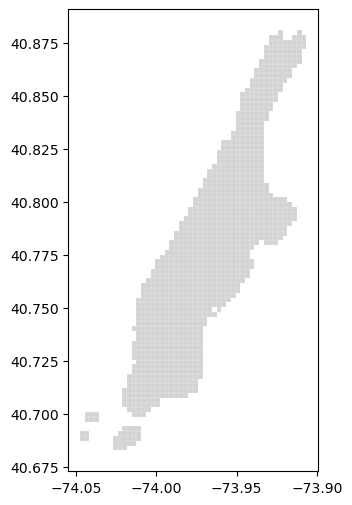

In [28]:
# show base grid
base_grid = combined_df.drop_duplicates(subset='grid_id')
base_gdf = gpd.GeoDataFrame(base_grid, geometry='geometry', crs='EPSG:4326')

# Plot both
ax = base_gdf.plot(color='lightgrey', edgecolor='white', linewidth=0.1, figsize=(6, 6))


# 2. Self-defined functions

In [29]:
def compute_global_busyness_percentile(df, feature_cols):
    """
    Compute globally comparable busyness score, z-score, and percentile based on selected features.

    Parameters:
        df (pd.DataFrame): Full dataset with all time slices.
        feature_cols (list): List of raw traffic features (e.g., subway, bike, taxi columns).

    Returns:
        pd.DataFrame: Original df with three new columns:
            - 'busyness_score'
            - 'busyness_zscore'
            - 'busyness_percentile'
    """
    # Standardize each feature
    scaler = StandardScaler()
    df[[f + '_norm' for f in feature_cols]] = scaler.fit_transform(df[feature_cols])

    # Calculate combined score
    df['busyness_score'] = df[[f + '_norm' for f in feature_cols]].sum(axis=1)

    # Standardize the combined score (global Z-score)
    score_scaler = StandardScaler()
    df['busyness_zscore'] = score_scaler.fit_transform(df[['busyness_score']])

    # Convert to percentile using normal distribution CDF
    df['busyness_percentile'] = norm.cdf(df['busyness_zscore'])

    return df


In [51]:
def plot_busyness_percentile_map(df, date_str, hour_int, busyness_level, ax=None, figsize=(6, 6), cmap='OrRd'):
    # 1. Filter data for the specified date and hour
    df_hour = df[(df['date'] == date_str) & (df['hour'] == hour_int)].copy()

    # 2. Convert to GeoDataFrame and reproject to Web Mercator
    gdf = gpd.GeoDataFrame(df_hour, geometry='geometry', crs='EPSG:4326').to_crs(epsg=3857)

    # 3. Drop rows with missing percentile values
    gdf = gdf.dropna(subset=[busyness_level])

    # 4. Prepare ax
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # 5. Plot the heatmap
    gdf.plot(
        ax=ax,
        column=busyness_level,
        cmap=cmap,
        linewidth=0.1,
        edgecolor='white',
        legend=True,
        legend_kwds={'title': busyness_level, 'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'}
    )

    ax.set_title(f"{busyness_level} - {date_str} {hour_int:02d}:00", fontsize=12)
    ax.axis("off")


# 3. Calculate `busyness_percentile`

In [31]:
feature_cols = [
    'subway_grid_ridership', 'subway_buffer_ridership',
    'bike_grid_trips', 'bike_buffer_ridership',
    'taxi_passenger_count'
]

combined_df = compute_global_busyness_percentile(combined_df, feature_cols)

In [32]:
combined_df[['grid_id','busyness_score', 'busyness_zscore', 'busyness_percentile']].head()


,grid_id,busyness_score,busyness_zscore,busyness_percentile
0,M-0001,-1.9751,-0.5443,0.2931
1,M-0002,-1.9751,-0.5443,0.2931
2,M-0003,-1.9751,-0.5443,0.2931
3,M-0004,-1.9751,-0.5443,0.2931
4,M-0005,-1.9751,-0.5443,0.2931


# 4. Define `busyness_level`based on busyness_percentile

## 4.1 Busyness_level_1: Evenly spaced bins from 0 - 1

In [33]:
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['1', '2', '3', '4', '5']
combined_df['busyness_level_1'] = pd.cut(combined_df['busyness_percentile'], bins=bins, labels=labels, include_lowest=True)


In [ ]:
# Check distribution
combined_df['busyness_level_1'].value_counts()

busyness_level_1
2    6281562
3    1612114
5    1230176
4     862548
1          0
Name: count, dtype: int64

The problems is there is no busyness_level equal to 1 in the evenly spaced bins.

In [35]:
combined_df['busyness_percentile'].describe()

count    9.9864e+06
mean     4.5303e-01
std      2.1620e-01
min      2.9310e-01
25%      3.0031e-01
50%      3.4166e-01
75%      5.2978e-01
max      1.0000e+00
Name: busyness_percentile, dtype: float64

From the above, we know that the minimum value of busyness_percentile is 0.2931, which explains why there is no `busyness_level_1` equal to 1 in the evenly spaced bins. We decided to make `busyness_level_1` as a baseline for comparison.

## 4.2 Busyness_level_2: Qcut

By applying qcut, every busyness level has similar amount of grid. The disadvantage is that it is hard to tell the exact bins.

In [36]:
combined_df['busyness_level_2'] = pd.qcut(
    combined_df['busyness_percentile'],
    q=5,
    labels=['1', '2', '3', '4', '5']
)


In [ ]:
# Check distribution
combined_df['busyness_level_2'].value_counts()

busyness_level_2
2    1998294
1    1997280
5    1997280
4    1997066
3    1996480
Name: count, dtype: int64

As expected, qcut make a balanced distribution.

## 4.3 Busyness_level_3: Evenly spaced bins from min to max

In [38]:
min_val = combined_df['busyness_percentile'].min()
max_val = combined_df['busyness_percentile'].max()
bins = np.linspace(min_val, max_val, 6)  # 5 equal-width bins from min to max
labels = ['1', '2', '3', '4', '5']

combined_df['busyness_level_3'] = pd.cut(
    combined_df['busyness_percentile'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [41]:
print(bins)

[0.29310194 0.43448155 0.57586116 0.71724078 0.85862039 1.        ]


In [ ]:
# Check distribution
combined_df['busyness_level_3'].value_counts()

busyness_level_3
1    6714811
2    1049602
5    1003123
3     664578
4     554286
Name: count, dtype: int64

# 4. Visulization

To get an intuitive sense of which method produces the most objective result, we plot the outputs for lunchtime on a random day (2024-05-01 12:00) and for midnight (2024-05-01 02:00), which is expected to be a non-busy period.

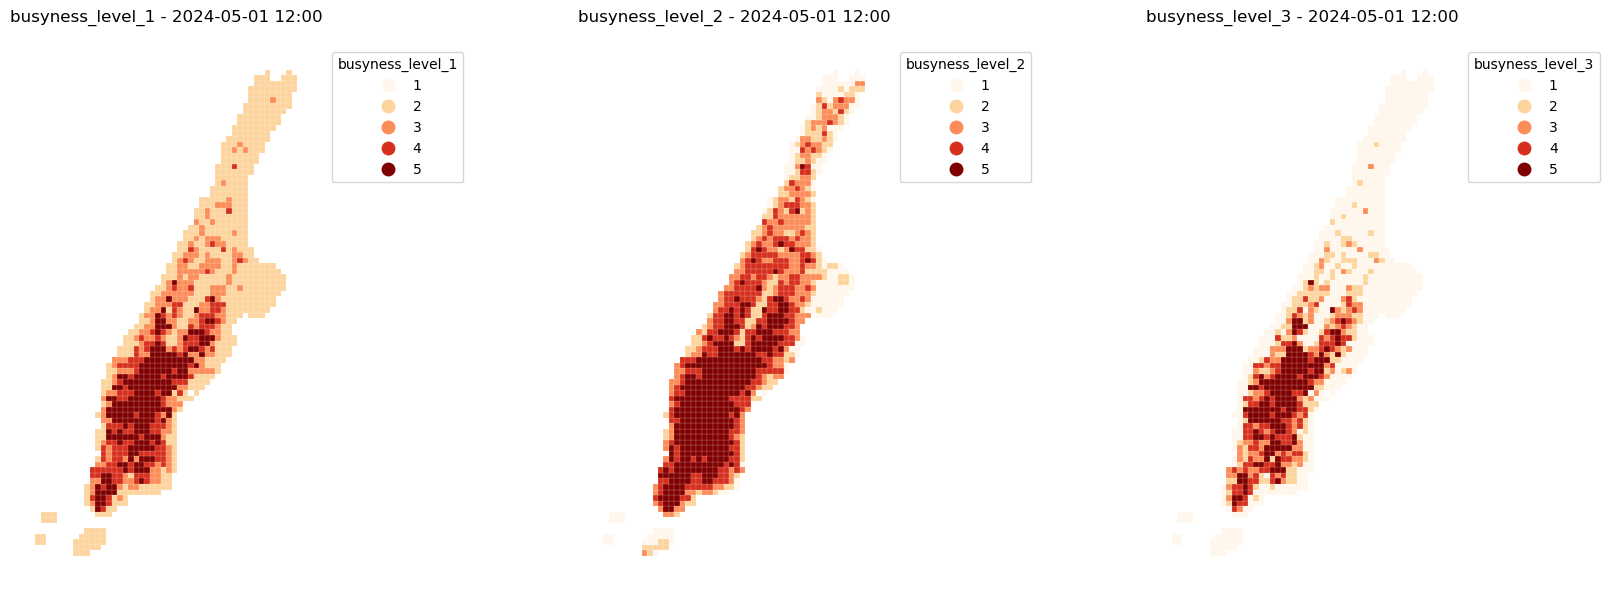

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_busyness_percentile_map(combined_df, '2024-05-01', 12, 'busyness_level_1', ax=axes[0])
plot_busyness_percentile_map(combined_df, '2024-05-01', 12, 'busyness_level_2', ax=axes[1])
plot_busyness_percentile_map(combined_df, '2024-05-01', 12, 'busyness_level_3', ax=axes[2])

plt.tight_layout()
plt.show()


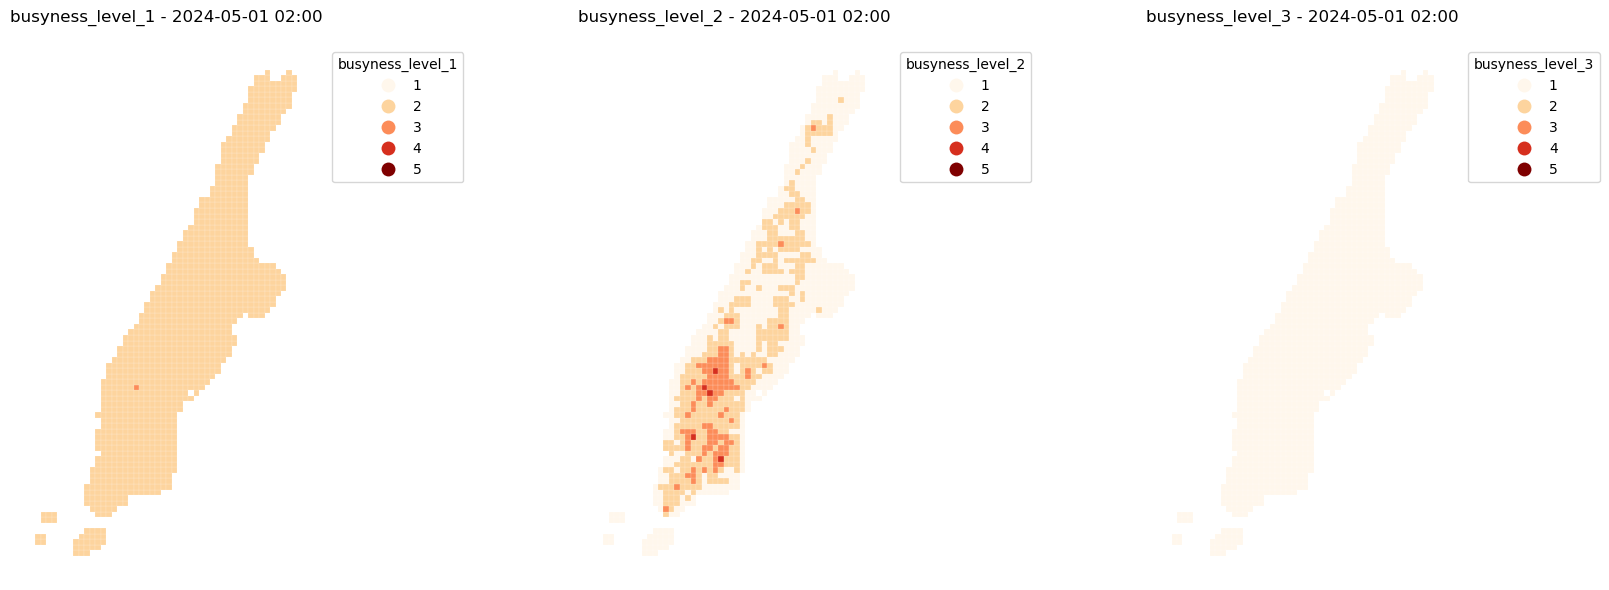

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_busyness_percentile_map(combined_df, '2024-05-01', 2, 'busyness_level_1', ax=axes[0])
plot_busyness_percentile_map(combined_df, '2024-05-01', 2, 'busyness_level_2', ax=axes[1])
plot_busyness_percentile_map(combined_df, '2024-05-01', 2, 'busyness_level_3', ax=axes[2])

plt.tight_layout()
plt.show()

In [58]:
combined_df[
    (combined_df['date'] == '2024-05-01') & (combined_df['hour'] == 2)
]['busyness_level_2'].value_counts().sort_index()


busyness_level_2
1    628
2    409
3     98
4      5
5      0
Name: count, dtype: int64

Based on the comparison, we prefer busyness_level_3. It provides a clearer distribution where all five levels are meaningfully populated, which makes the classification more interpretable. In contrast, busyness_level_2 shows busyness variety even at 2:00 AM, where busyness is expected to be minimal. This undermines its ability to reflect actual variation in activity.

# 5. Drop levels 1/2 and rename level 3

In [59]:
combined_df = combined_df.drop(columns=[col for col in ['busyness_level_1', 'busyness_level_2'] if col in combined_df.columns])
combined_df = combined_df.rename(columns={'busyness_level_3': 'busyness_level'})


# 6. Save to pkl 

In [ ]:
# File has already been saved; this line is now commented out to prevent overwriting
# Check google drive for the file
# combined_df.to_pickle("combined_with_all_columns_and_busyness_level.pkl")

In [62]:
combined_df.columns

Index(['date', 'hour', 'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm',
       'grid_id', 'lat', 'lon', 'geometry', 'is_holiday', 'restaurant_count',
       'subway_grid_ridership', 'subway_buffer_ridership', 'bike_grid_trips',
       'bike_buffer_ridership', 'taxi_passenger_count', 'event_count',
       'population', 'subway_grid_ridership_norm',
       'subway_buffer_ridership_norm', 'bike_grid_trips_norm',
       'bike_buffer_ridership_norm', 'taxi_passenger_count_norm',
       'busyness_score', 'busyness_zscore', 'busyness_percentile',
       'busyness_level'],
      dtype='object')

In [ ]:
columns_to_keep = [
    'date', 'hour', 'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm',
       'grid_id', 'lat', 'lon', 'geometry', 'is_holiday', 'restaurant_count',
       'subway_grid_ridership', 'subway_buffer_ridership', 'bike_grid_trips',
       'bike_buffer_ridership', 'taxi_passenger_count', 'event_count',
       'population', 'busyness_percentile',
       'busyness_level'
]

combined_df_light = combined_df[columns_to_keep]

# File has already been saved; this line is now commented out to prevent overwriting
# Check google drive for the file
# combined_df_light.to_pickle("combined_light_with_busyness_level.pkl")